In [1]:
import warnings
import autograd.numpy as np  
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # remove if linear scale


from functions import (
    cost,create_layers_batch,  feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy, plot_MSE_to_Iter, print_output, calculate_nlayer_nn
)
from activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der
)
from train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)  

In [2]:
# Setting seed for reproducibility
np.random.seed(42)
n = 200

# Creating a grid of n=200 points drawn from the random distribution
x = np.random.uniform(-1, 1, n)

# Setting up Runge's function, 1 normal and 1 with added noise
y = 1.0 / (1 + 25 * x**2) + np.random.normal(0, 0.1, x.shape)

# Calculating sample statistics
x_mean = np.mean(x)
x_variance = np.std(x, ddof=1) #sample variance

#Scaling x values for a visual comparison
x_st = (x - x_mean) / x_variance

# Now we split the dataset for training and testing (using the standardized x values) and noisy Runge
X_train, X_test, y_train, y_test = train_test_split(x_st, y, test_size=0.2, random_state = 42)

# ---- Grid over learning rates ----
poly_degree = 7
inputs_train = np.array(polynomial_features(X_train, poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test, poly_degree))
targets_test = y_test.reshape(-1, 1)

network_input_size = poly_degree + 1

# best 2 layers NN from excercise b)

In [3]:
results, histories_best = calculate_nlayer_nn(
    inputs_train = inputs_train, 
    targets_train = targets_train,
    inputs_test = inputs_test, 
    targets_test = targets_test, 
    n_iter=1000,
    learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
    network_input_size = network_input_size,
    layer_output_sizes=[100,100, 1],
    activation_funcs=[sigmoid,sigmoid, ReLU],
    activation_ders=[sigmoid_der,sigmoid_der, ReLU_der],
    train_network_type = train_network_RMSprop)
print_output(results, gd_type = 'RMSprop')


=== Learning rate summary RMSprop ===
lr=0.0001    train MSE=0.012961  test MSE=0.017416
lr=0.001     train MSE=0.017201  test MSE=0.026156
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423


In [4]:
set_of_activ = [[sigmoid,sigmoid, ReLU],
                [sigmoid,sigmoid, leaky_ReLu],
                [ReLU,sigmoid, ReLU],
                [sigmoid,ReLU,sigmoid],
                [sigmoid,ReLU, leaky_ReLu],
                [ReLU,sigmoid, leaky_ReLu],
                [sigmoid,leaky_ReLu,sigmoid],
                [leaky_ReLu,sigmoid, leaky_ReLu]
               ]
set_of_activ_der = [[sigmoid_der,sigmoid_der, ReLU_der],
                [sigmoid_der,sigmoid_der, leaky_ReLU_der],
                [ReLU_der,sigmoid_der, ReLU_der],
                [sigmoid_der,ReLU_der,sigmoid_der],
                [sigmoid_der,ReLU_der, leaky_ReLU_der],
                [ReLU_der,sigmoid_der, leaky_ReLU_der],
                [sigmoid_der,leaky_ReLU_der,sigmoid_der],
                [leaky_ReLU_der,sigmoid_der, leaky_ReLU_der]
               ]
for i in range(len(set_of_activ)):
    results, histories_best = calculate_nlayer_nn(
        inputs_train = inputs_train, 
        targets_train = targets_train,
        inputs_test = inputs_test, 
        targets_test = targets_test, 
        n_iter=1000,
        learning_rates = [1e-4, 1e-3, 1e-2, 1e-1],
        network_input_size = network_input_size,
        layer_output_sizes=[100,100, 1],
        activation_funcs=set_of_activ[i],
        activation_ders=set_of_activ_der[i],
        train_network_type = train_network_RMSprop)
    set__of_funct =  (", ".join(getattr(f, "__name__", repr(f)) for f in set_of_activ[i]))
    print_output(results, gd_type = set__of_funct)


=== Learning rate summary sigmoid, sigmoid, ReLU ===
lr=0.0001    train MSE=0.012961  test MSE=0.017416
lr=0.001     train MSE=0.017201  test MSE=0.026156
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Learning rate summary sigmoid, sigmoid, leaky_ReLu ===
lr=0.0001    train MSE=0.012531  test MSE=0.015296
lr=0.001     train MSE=0.019632  test MSE=0.023165
lr=0.01      train MSE=0.082866  test MSE=0.075098
lr=0.1       train MSE=0.185619  test MSE=0.140252


/Users/natalliadanilchanka/anaconda3/lib/python3.11/site-packages/autograd/tracer.py:48: RuntimeWarning: overflow encountered in exp
  return f_raw(*args, **kwargs)



=== Learning rate summary ReLU, sigmoid, ReLU ===
lr=0.0001    train MSE=0.015858  test MSE=0.021318
lr=0.001     train MSE=0.017918  test MSE=0.025157
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Learning rate summary sigmoid, ReLU, sigmoid ===
lr=0.0001    train MSE=0.142655  test MSE=0.086583
lr=0.001     train MSE=0.159962  test MSE=0.118903
lr=0.01      train MSE=0.160468  test MSE=0.116423
lr=0.1       train MSE=0.160468  test MSE=0.116423

=== Learning rate summary sigmoid, ReLU, leaky_ReLu ===
lr=0.0001    train MSE=0.022348  test MSE=0.026969
lr=0.001     train MSE=0.187040  test MSE=0.144040
lr=0.01      train MSE=1.107444  test MSE=1.018798
lr=0.1       train MSE=1.295505  test MSE=1.284475

=== Learning rate summary ReLU, sigmoid, leaky_ReLu ===
lr=0.0001    train MSE=0.010118  test MSE=0.013962
lr=0.001     train MSE=0.009259  test MSE=0.019504
lr=0.01      train MSE=0.018433  test MSE=0.024256
lr=0.1       tra

##  Test as functions of the number of hidden layers and nodes. 

Do you see signs of overfitting? 

We have decided to use sigmoid function for hidden layers and leaky_ReLu for output

In [6]:
layer_output_sizes_set = [[100, 1],[100,100, 1],[100,100,100, 1],[100,100,100,100, 1],[100,100,100,100,100, 1]]


set_of_activ = [[sigmoid, leaky_ReLu],
                [sigmoid,sigmoid, leaky_ReLu],
                [sigmoid,sigmoid,sigmoid, leaky_ReLu],
                [sigmoid,sigmoid,sigmoid,sigmoid, leaky_ReLu],
                [sigmoid,sigmoid,sigmoid,sigmoid,sigmoid, leaky_ReLu]
               ]
set_of_activ_der = [[sigmoid_der, leaky_ReLU_der],
                    [sigmoid_der,sigmoid_der, leaky_ReLU_der],
                    [sigmoid_der,sigmoid_der,sigmoid_der, leaky_ReLU_der],
                    [sigmoid_der,sigmoid_der,sigmoid_der,sigmoid_der, leaky_ReLU_der],
                    [sigmoid_der,sigmoid_der,sigmoid_der,sigmoid_der,sigmoid_der, leaky_ReLU_der]
               ]

In [7]:
for i in range(len(layer_output_sizes_set)):
    results, histories_best = calculate_nlayer_nn(
        inputs_train = inputs_train, 
        targets_train = targets_train,
        inputs_test = inputs_test, 
        targets_test = targets_test, 
        n_iter=1000,
        learning_rates = [1e-4],
        network_input_size = network_input_size,
        layer_output_sizes=layer_output_sizes_set[i],
        activation_funcs=set_of_activ[i],
        activation_ders=set_of_activ_der[i],
        train_network_type = train_network_RMSprop)
    set__of_funct =  (", ".join(getattr(f, "__name__", repr(f)) for f in layer_output_sizes_set[i]))
    print_output(results, gd_type = set__of_funct)


=== Learning rate summary 100, 1 ===
lr=0.0001    train MSE=0.063464  test MSE=0.074437

=== Learning rate summary 100, 100, 1 ===
lr=0.0001    train MSE=0.012531  test MSE=0.015296

=== Learning rate summary 100, 100, 100, 1 ===
lr=0.0001    train MSE=0.010148  test MSE=0.017754

=== Learning rate summary 100, 100, 100, 100, 1 ===
lr=0.0001    train MSE=0.008926  test MSE=0.014744

=== Learning rate summary 100, 100, 100, 100, 100, 1 ===
lr=0.0001    train MSE=0.008416  test MSE=0.013246


## Heatmap for report


=== Train MSE (rows=hidden nodes, cols=hidden layers) ===
              1           2           3           4           5
10   1.6684e-01  1.4118e+00  3.2303e-01  9.4105e-02  3.5933e-02
50   5.6626e-02  1.4210e-02  1.2375e-02  8.8359e-03  7.9473e-03
75   1.6749e-01  1.2536e-02  9.5587e-03  8.9048e-03  7.9743e-03
100  6.3464e-02  1.2531e-02  1.0148e-02  8.9258e-03  8.4163e-03

=== Test  MSE (rows=hidden nodes, cols=hidden layers) ===
              1           2           3           4           5
10   1.2205e-01  1.3731e+00  3.2162e-01  7.1329e-02  3.3731e-02
50   4.6132e-02  2.0259e-02  1.6931e-02  1.4984e-02  1.3652e-02
75   1.2560e-01  1.5200e-02  1.9502e-02  1.4343e-02  1.3437e-02
100  7.4437e-02  1.5296e-02  1.7754e-02  1.4744e-02  1.3246e-02

Best Train MSE = 7.947251e-03 at hidden_nodes=50, hidden_layers=5
Best Test  MSE = 1.324586e-02 at hidden_nodes=100, hidden_layers=5


/var/folders/2x/86b82jhn7m5cwtv2m75stgq80000gn/T/ipykernel_13893/2740392876.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(train_df.applymap(lambda v: f"{v:.4e}"))
/var/folders/2x/86b82jhn7m5cwtv2m75stgq80000gn/T/ipykernel_13893/2740392876.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(test_df.applymap(lambda v: f"{v:.4e}"))


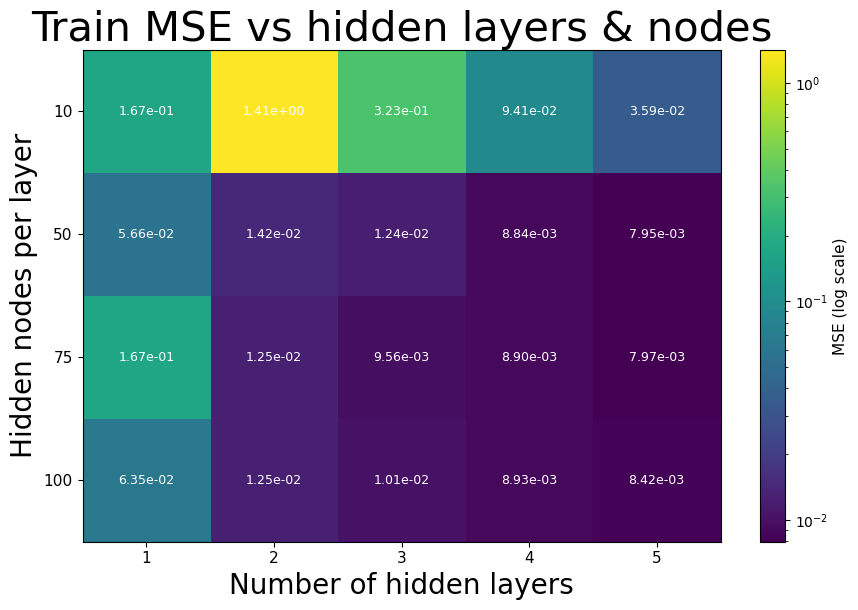

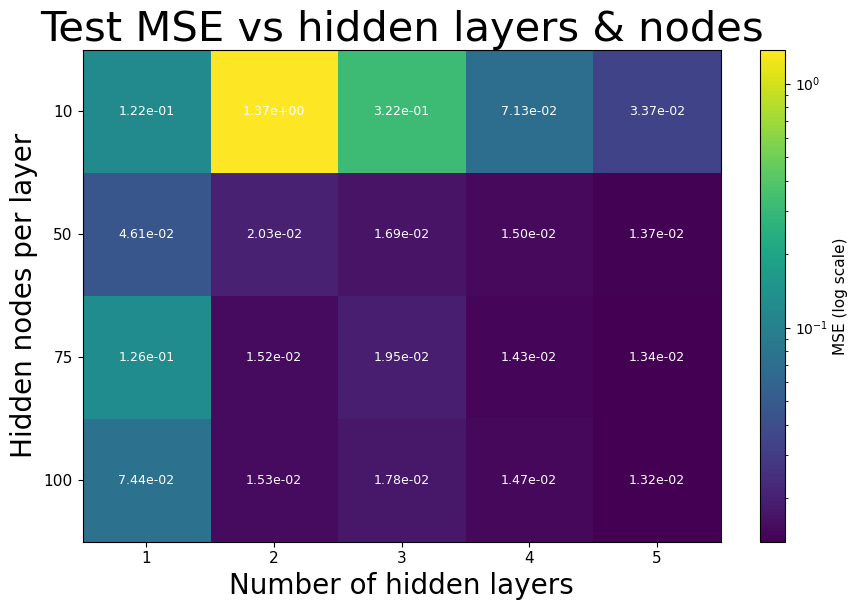

In [10]:
# Grid
hidden_nodes_list = [10, 50, 75, 100]   # rows
hidden_layers_list = [1, 2, 3, 4, 5]    # cols

# Storage
train_mse_mat = np.zeros((len(hidden_nodes_list), len(hidden_layers_list)), dtype=float)
test_mse_mat  = np.zeros((len(hidden_nodes_list), len(hidden_layers_list)), dtype=float)

for i, n_nodes in enumerate(hidden_nodes_list):
    for j, n_layers in enumerate(hidden_layers_list):
        layer_output_sizes = [n_nodes] * n_layers + [1]
        activation_funcs = [sigmoid] * n_layers + [leaky_ReLu]
        activation_ders  = [sigmoid_der] * n_layers + [leaky_ReLU_der]

        results, histories_best = calculate_nlayer_nn(
            inputs_train=inputs_train, 
            targets_train=targets_train,
            inputs_test=inputs_test, 
            targets_test=targets_test, 
            n_iter=1000,
            learning_rates=[1e-4],
            network_input_size=network_input_size,
            layer_output_sizes=layer_output_sizes,
            activation_funcs=activation_funcs,
            activation_ders=activation_ders,
            train_network_type=train_network_RMSprop
        )

        _, tr_mse, te_mse = results[0]
        train_mse_mat[i, j] = float(tr_mse)
        test_mse_mat[i, j]  = float(te_mse)

# ---- Print as text (tables) ----
train_df = pd.DataFrame(train_mse_mat, index=hidden_nodes_list, columns=hidden_layers_list)
test_df  = pd.DataFrame(test_mse_mat,  index=hidden_nodes_list, columns=hidden_layers_list)

print("\n=== Train MSE (rows=hidden nodes, cols=hidden layers) ===")
print(train_df.applymap(lambda v: f"{v:.4e}"))

print("\n=== Test  MSE (rows=hidden nodes, cols=hidden layers) ===")
print(test_df.applymap(lambda v: f"{v:.4e}"))

# Best configs
best_train_idx = np.unravel_index(np.argmin(train_mse_mat), train_mse_mat.shape)
best_test_idx  = np.unravel_index(np.argmin(test_mse_mat),  test_mse_mat.shape)
best_train_nodes = hidden_nodes_list[best_train_idx[0]]
best_train_layers = hidden_layers_list[best_train_idx[1]]
best_test_nodes = hidden_nodes_list[best_test_idx[0]]
best_test_layers = hidden_layers_list[best_test_idx[1]]

print(f"\nBest Train MSE = {train_mse_mat[best_train_idx]:.6e} "
      f"at hidden_nodes={best_train_nodes}, hidden_layers={best_train_layers}")
print(f"Best Test  MSE = {test_mse_mat[best_test_idx]:.6e} "
      f"at hidden_nodes={best_test_nodes}, hidden_layers={best_test_layers}")

# ---- Heatmap helper ----
def plot_heatmap(data, title, x_labels, y_labels, cbar_label="MSE", use_log=True):
    fig, ax = plt.subplots(figsize=(1.2*len(x_labels)+3, 0.8*len(y_labels)+3))
    if use_log:
        vmin = max(data.min(), 1e-12)
        im = ax.imshow(data, aspect='auto', cmap='viridis', norm=LogNorm(vmin=vmin, vmax=data.max()))
    else:
        im = ax.imshow(data, aspect='auto', cmap='viridis')

    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=11)
    ax.set_xlabel('Number of hidden layers', fontsize=20)
    ax.set_ylabel('Hidden nodes per layer', fontsize=20)
    ax.set_title(title, fontsize=30)

    # annotate cells
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r, c]:.2e}", ha='center', va='center', color='white', fontsize=9)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"{cbar_label}" + (" (log scale)" if use_log else ""), fontsize=11)
    plt.tight_layout()
    plt.show()

# ---- Separate heatmaps ----
plot_heatmap(train_mse_mat, "Train MSE vs hidden layers & nodes",
             x_labels=hidden_layers_list, y_labels=hidden_nodes_list, cbar_label="MSE", use_log=True)

plot_heatmap(test_mse_mat,  "Test MSE vs hidden layers & nodes",
             x_labels=hidden_layers_list, y_labels=hidden_nodes_list, cbar_label="MSE", use_log=True)
